In [7]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [8]:
from geoflow import FlowDataFrame
from geoflow import read_csv, read_file

# Basic Usage

In [9]:
fdf = read_csv('./data/sz_data/sz_taxi_flow.csv', use_cols=['ox', 'oy', 'dx', 'dy'], crs='EPSG:4326')
fdf.shape, type(fdf)

((10000, 10), geoflow.flowdataframe.FlowDataFrame)

In [10]:
df = pd.read_csv('./data/sz_data/sz_taxi_flow.csv')
fdf = FlowDataFrame(df, use_cols=['ox', 'oy', 'dx', 'dy'], crs='EPSG:4326')
type(fdf)

geoflow.flowdataframe.FlowDataFrame

In [11]:
fdf.to_crs(4526, inplace=True)
type(fdf)

geoflow.flowdataframe.FlowDataFrame

In [12]:
type(fdf.iloc[:100])

geopandas.geodataframe.GeoDataFrame

In [6]:
fdf = fdf.to_crs(4526)
type(fdf)

geopandas.geodataframe.GeoDataFrame

In [10]:
fdf = fdf.to_crs(4526)
fdf.density, fdf.volume

AttributeError: 'GeoDataFrame' object has no attribute 'density'

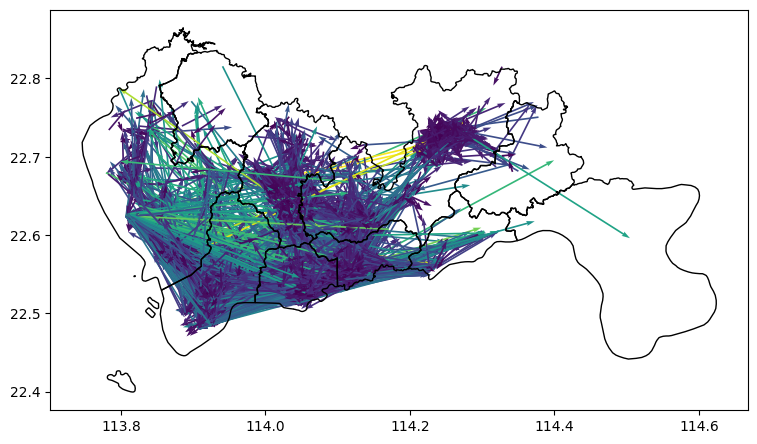

In [6]:
fdf.to_crs(4326, inplace=True)
gdf = gpd.read_file('./data/sz_data/sz_border.gpkg')
ax = fdf.plot(figsize=(9, 6), column='distance')
gdf.plot(ax=ax, facecolor="none", edgecolor="black");

In [7]:
fdf = read_file('./data/sys_flow/sys_flow_dataset2.gpkg')
fdf.head(1)

,index,ox,oy,dx,dy,angle,length,flow_type,type_num,geometry
0,0,0.933863,0.056809,0.977145,0.494712,1.4725,1.099471,scatter2,7,"LINESTRING (0.93386 0.05681, 0.97714 0.49471)"


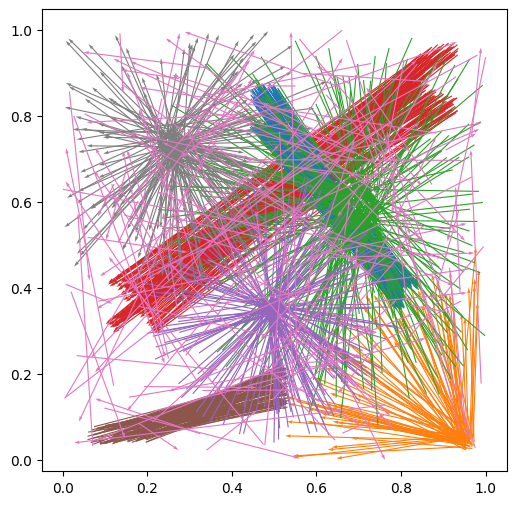

In [8]:
from matplotlib.colors import ListedColormap
labels = fdf['flow_type']
unique_labels = list(set(labels))
num_unique_labels = len(unique_labels)
cmap = ListedColormap(plt.cm.tab10.colors[:num_unique_labels]) 
label_to_color = {label: cmap(i) for i, label in enumerate(unique_labels)}
colors = [label_to_color[label] for label in labels]

fdf.plot(color=colors, figsize=(6, 6));

# K & L Function

In [9]:
from shapely.geometry import Polygon
from geoflow import k_func, l_func
from geoflow import pairwise_distances

In [10]:
flow_num = 5000
xlim, ylim = (0, 1), (0, 1)

oxs = np.random.uniform(xlim[0], xlim[1], flow_num)
oys = np.random.uniform(ylim[0], ylim[1], flow_num)
dxs = np.random.uniform(xlim[0], xlim[1], flow_num)
dys = np.random.uniform(ylim[0], ylim[1], flow_num)
fdf = FlowDataFrame({'ox': oxs, 'oy': oys, 'dx': dxs, 'dy': dys}, use_cols=['ox', 'oy', 'dx', 'dy'], crs='EPSG:4526')

In [11]:
dis_matrix = pairwise_distances(fdf, distance='max')
dis_matrix.shape

(5000, 5000)

## K Function

In [12]:
polygon = Polygon([(0.3, 0.3), (0.7, 0.3), (0.7, 0.7), (0.3, 0.7)])
x, y = polygon.exterior.xy
r_list, kr_list = k_func(fdf, dr=0.01, dis_matrix=dis_matrix, distance='max', mask=polygon)

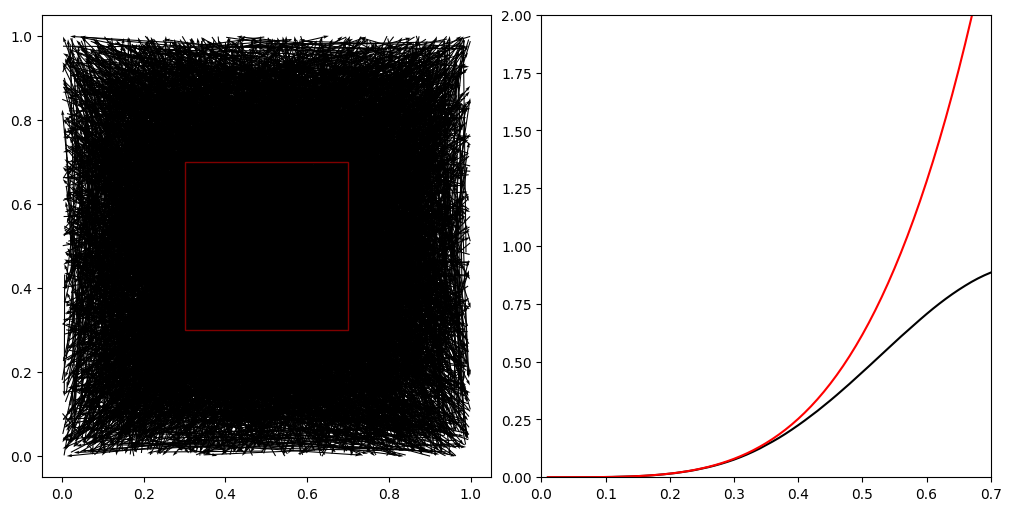

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

fdf.plot(figsize=(6, 6), ax=ax1)
ax1.fill(x, y, alpha=0.5, fc='none', ec='red')

ax2.plot(r_list, kr_list, 'k-')
ax2.plot(r_list, np.pi**2 * r_list**4, 'r-')
ax2.set_xlim(0, 0.7)
ax2.set_ylim(0, 2);

## L Function

In [14]:
polygon = Polygon([(0.3, 0.3), (0.7, 0.3), (0.7, 0.7), (0.3, 0.7)])
x, y = polygon.exterior.xy
r_list, lr_list = l_func(fdf, dr=0.01, dis_matrix=dis_matrix, distance='max', mask=polygon)

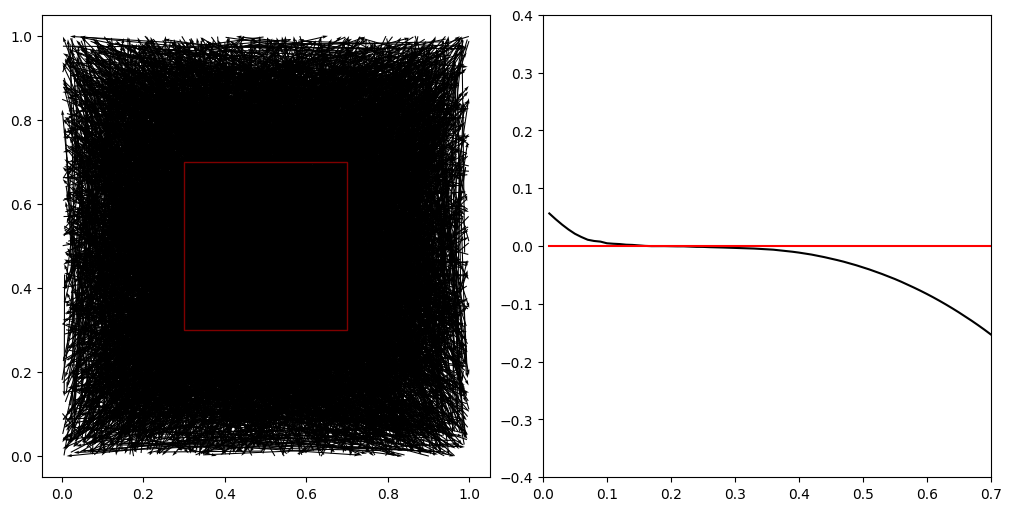

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

fdf.plot(figsize=(6, 6), ax=ax1)
ax1.fill(x, y, alpha=0.5, fc='none', ec='red')

ax2.plot(r_list, lr_list, 'k-')
ax2.plot(r_list, np.zeros_like(r_list), 'r-')
ax2.set_xlim(0, 0.7)
ax2.set_ylim(-0.4, 0.4);